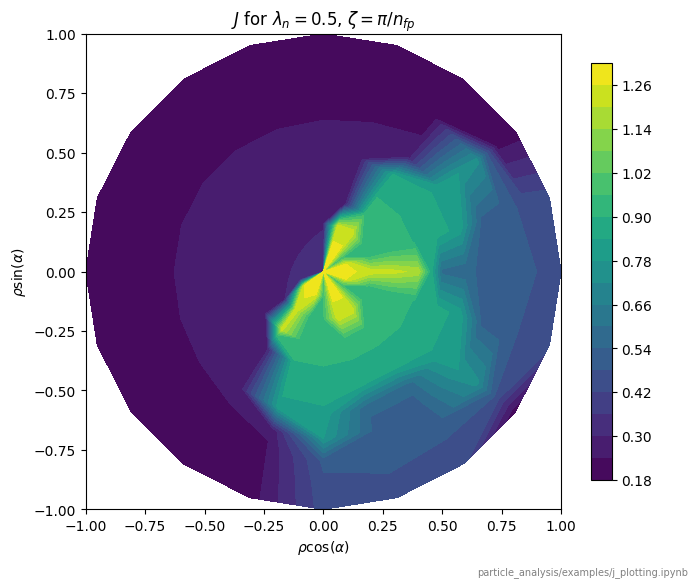

In [1]:
"""
Simple J contour plot for lambda_n=0.5 with medium resolution.
"""

import numpy as np
import matplotlib.pyplot as plt
from particle_analysis import (
    trace_field_line, find_wells, compute_j_well, get_global_B_range,
    load_boozmn, get_example_boozmn,
)

# Parameters 
LAMBDA_N = 0.5
N_ALPHA = 20
N_RHO = 11
N_ZETA = 4096

# Load Boozer equilibrium
boozer = load_boozmn(get_example_boozmn())
ns, nfp = boozer['ns'], boozer['nfp']
R_MAJOR = boozer['R_major']  # major radius from the boozmn file

# Alpha and rho arrays
alpha_values = np.linspace(0, 2 * np.pi, N_ALPHA, endpoint=False)
rho_idx = np.unique(np.round(np.linspace(0, 1, N_RHO) ** 2 * (ns - 1)).astype(int))
rho_values = np.sqrt(rho_idx / (ns - 1))

# Compute global B bounds and bounce threshold
B_min, B_max = get_global_B_range(boozer)
B_bounce = B_min + LAMBDA_N * (B_max - B_min)

# Trace field lines for all (rho, alpha)
traces = {
    (s_idx, a_idx): trace_field_line(boozer, s_idx, alpha, n_zeta=N_ZETA)
    for a_idx, alpha in enumerate(alpha_values)
    for s_idx in rho_idx
}

def find_well_near_target(wells, target_zeta):
    """Pick well containing target_zeta (else, closest center)."""
    if not wells:
        return None
    containing = [w for w in wells if w[0] <= target_zeta <= w[1]]
    if containing:
        return min(containing, key=lambda w: abs((w[0] + w[1]) / 2 - target_zeta))
    return min(wells, key=lambda w: abs((w[0] + w[1]) / 2 - target_zeta))

target_zeta = np.pi / nfp

# Compute J for each (alpha, rho)
J_grid = np.full((len(alpha_values), len(rho_idx)), np.nan)
for a_idx in range(len(alpha_values)):
    for r_idx, s_idx in enumerate(rho_idx):
        zeta, B = traces[(s_idx, a_idx)]
        wells = find_wells(zeta, B, B_bounce)
        well = find_well_near_target(wells, target_zeta)
        if well is not None:
            iota = boozer['iota'][s_idx]
            G = boozer['Boozer_G'][s_idx]
            I = boozer['Boozer_I'][s_idx]
            norm = abs(G + iota * I) / (2 * np.pi * R_MAJOR / nfp)
            J_grid[a_idx, r_idx] = compute_j_well(zeta, B, well, B_bounce, norm)

# For polar plot: close circle in alpha
alpha_plot = np.append(alpha_values, 2 * np.pi)
J_plot = np.vstack([J_grid, J_grid[0:1, :]])
RHO, ALPHA = np.meshgrid(rho_values, alpha_plot)
X = RHO * np.cos(ALPHA)
Y = RHO * np.sin(ALPHA)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(X, Y, J_plot, levels=20, cmap='viridis')
fig.colorbar(c, ax=ax, shrink=0.85)
ax.set(xlabel=r'$\rho\cos(\alpha)$', ylabel=r'$\rho\sin(\alpha)$',
       title=r'$J$ for $\lambda_n=0.5$, $\zeta=\pi/n_{fp}$',
       aspect='equal', xlim=(-1,1), ylim=(-1,1))

fig.text(
    0.99, 0.01,
    "particle_analysis/examples/j_plotting.ipynb",
    ha="right", va="bottom", fontsize=7, color="gray"
)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

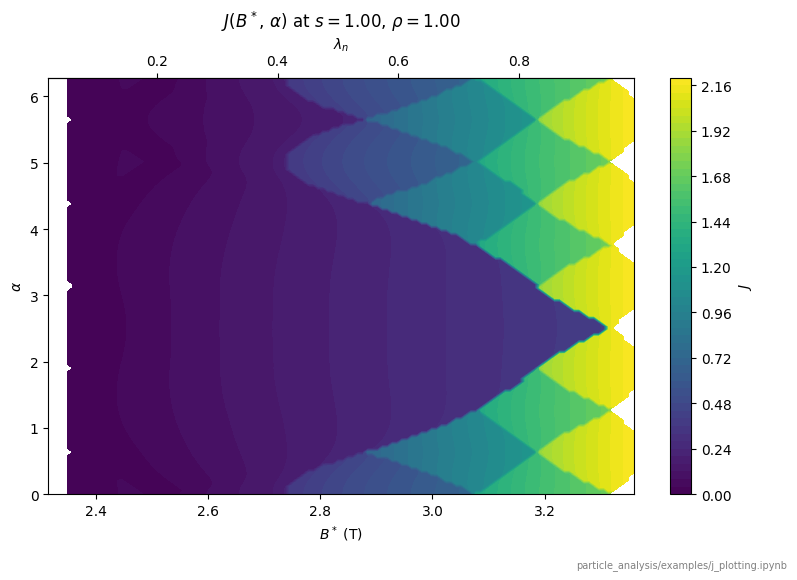

In [2]:
"""
Simple J plot for rho=s=1.00 with medium resolution.
"""
import numpy as np
import matplotlib.pyplot as plt

S_TARGET = 1.0
N_ALPHA = N_BSTAR = 120
LAMBDA_MIN, LAMBDA_MAX = 0.02, 0.99
N_ZETA = 4096
R_MAJOR = boozer['R_major']

s_idx = int(round(S_TARGET * (ns - 1)))
rho = np.sqrt(s_idx / (ns - 1))
iota = boozer['iota'][s_idx]
G = boozer['Boozer_G'][s_idx]
I = boozer['Boozer_I'][s_idx]
norm = abs(G + iota * I) / (2 * np.pi * R_MAJOR / nfp)

alpha_grid = np.linspace(0, 2 * np.pi, N_ALPHA)
lambda_n = np.linspace(LAMBDA_MIN, LAMBDA_MAX, N_BSTAR)
B_star = B_min + lambda_n * (B_max - B_min)
target_zeta = np.pi / nfp
traces = [trace_field_line(boozer, s_idx, a, n_zeta=N_ZETA) for a in alpha_grid]

J_bstar = np.full((N_ALPHA, N_BSTAR), np.nan)
for a_idx, (zeta, B) in enumerate(traces):
    for b_idx, B_bounce in enumerate(B_star):
        well = find_well_near_target(find_wells(zeta, B, B_bounce), target_zeta)
        if well is not None:
            J_bstar[a_idx, b_idx] = compute_j_well(zeta, B, well, B_bounce, norm)

B_MESH, A_MESH = np.meshgrid(B_star, alpha_grid)
fig, ax = plt.subplots(figsize=(8, 6))
c = ax.contourf(B_MESH, A_MESH, J_bstar, levels=60, cmap='viridis')
fig.colorbar(c, ax=ax, label=r'$J$')
ax.set(xlabel=r'$B^*$ (T)', ylabel=r'$\alpha$',
       title=rf'$J(B^*,\,\alpha)$ at $s={S_TARGET:.2f},\,\rho={rho:.2f}$',
       ylim=(0, 2 * np.pi))

secax = ax.secondary_xaxis(
    'top',
    functions=(lambda b: (b - B_min) / (B_max - B_min),
               lambda l: B_min + l * (B_max - B_min)),
)
secax.set_xlabel(r'$\lambda_n$')

fig.text(0.99, 0.01, "particle_analysis/examples/j_plotting.ipynb",
         ha="right", va="bottom", fontsize=7, color="gray")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()